# Calibrating an LLM Classifier with MCGrad
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/facebookincubator/MCGrad/blob/main/tutorials/02_calibrating_llm_outputs.ipynb)
This tutorial demonstrates the **MCGrad** workflow on a real LLM classification task. The setup follows the structure of [Tutorial 01](01_mcgrad_core.ipynb) — the difference is that the base model is a large language model rather than a logistic regression.
We use Claude Opus 4.6 to classify political texts from the [Comparative Agendas Project (CAP)](https://www.comparativeagendas.net/) as related to *Law and Crime*. The LLM is prompted to estimate `P(Yes)` directly (verbalized confidence), giving us a probability score that's the natural analogue to a classifier's `predict_proba` output. Although the LLM achieves strong discriminative performance, its scores are systematically miscalibrated — both globally and across important sub-populations — and standard global-calibration methods like isotonic regression don't fix the per-segment errors.
## Outline
1. **Setup** — Load the pre-computed Opus inference outputs and split into train/test
2. **Assessing Model Performance, Calibration and Multicalibration** — Show the LLM's discriminative quality, global calibration, and the per-segment miscalibration that survives isotonic regression
3. **MCGrad Basics** — Fit MCGrad to fix multicalibration error
4. **Model Evaluation** — Compare base LLM, isotonic regression, and MCGrad across calibration and ranking metrics
5. **Putting the calibrated scores to use** — Two practical applications: per-sub-population prevalence estimation and threshold-based decisions
6. **Next Steps** — Pointers to the application-focused tutorial and deeper documentation
**Expected runtime:** ~3 minutes on a laptop CPU.

## 1. Setup
MCGrad must be installed. See the [installation guide](https://mcgrad.dev/docs/installation) for additional instructions.

In [1]:
# Run this cell when working in Colab or in a fresh environment.
# %pip install mcgrad

In [2]:
import os
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics as skmetrics
from sklearn.model_selection import train_test_split

import mcgrad
from mcgrad import metrics, methods, plotting

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'MCGrad version: {mcgrad.__version__}')

/Users/flinder/.local/lib/python3.12/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


MCGrad version: 0.1.4.dev3+ga17e89c1b


We reuse a few small helpers from `mcgrad.tutorials.helpers` for plot styling and to format the comparison tables consistently with Tutorial 01.

In [3]:
from mcgrad.tutorials.helpers import (
    combine_segment_calibration_plots,
    configure_logging,
    format_calibration_metrics_table,
    setup_plotting,
)

setup_plotting()
configure_logging()

### 1.1 Dataset and ML task
We use 30,000 documents from the Comparative Agendas Project, with expert ground-truth labels for whether each document primarily addresses **Law and Crime** (the binary outcome). Each document was classified by Claude Opus 4.6 in two independent campaigns:
- a **binary Yes/No** classification (column `llm_yes`)
- a **direct probability elicitation** of P(Yes) without first committing to an answer (column `pyn_score`).
This tutorial focuses on the elicited probability as the analogue to a logistic regression's `predict_proba` output.
The 30K sample spans six sub-populations across four countries and four languages — Danish parliamentary questions, Spanish parliamentary questions, US congressional bills, Belgian newspaper articles, Spanish online media, and Belgian TV news. We use **all six** in this tutorial.
| Column | Description |
|---|---|
| `country`     | Country of origin (Belgium, Denmark, Spain, USA) |
| `doc_type`    | Document type (parliamentary_question, bill, newspaper) |
| `party`       | Political party where applicable (52 unique values) |
| `decade`      | Decade the document was authored (1940s–2010s) |
| `text_len`    | Document length in characters |
| `pyn_score`   | LLM-elicited P(Yes) — the **base model output** |
| `llm_yes`     | LLM Yes/No classification (used for diagnostics) |
| `law_crime`   | **Binary ground-truth label** |
The data lives in the [multicalibrated_llm_measurement](https://github.com/facebookresearch/multicalibrated_llm_measurement) repo accompanying the paper. The cell below downloads it once and caches locally — re-runs are instant.

In [4]:
import urllib.request
from pathlib import Path

DATA_BASE = (
    'https://raw.githubusercontent.com/facebookresearch/'
    'multicalibrated_llm_measurement/main/cap_analysis/data'
)
CACHE_DIR = Path.home() / '.cache' / 'mcgrad_tutorials' / 'cap_data'

def fetch_cap_file(rel_path: str) -> str:
    """Download a file from the public CAP data repo if not cached."""
    local = CACHE_DIR / rel_path
    if not local.exists():
        local.parent.mkdir(parents=True, exist_ok=True)
        url = f'{DATA_BASE}/{rel_path}'
        print(f'Downloading {rel_path}...')
        urllib.request.urlretrieve(url, local)
    return str(local)

sample = pd.read_csv(fetch_cap_file('opus_30k_sample.csv'))
sample['party'] = sample['party'].fillna('unknown')
sample['text_len'] = sample['text'].str.len()

binary = pd.read_csv(
    fetch_cap_file('inference_output/claude-opus-30k-binary/merged.csv')
).drop_duplicates(subset='id', keep='first')
binary['llm_yes'] = (binary['answer'].str.lower() == 'yes').astype(int)

pyn = pd.read_csv(
    fetch_cap_file('inference_output/claude-opus-30k-pyn/merged.csv')
)

data = sample.merge(binary[['id', 'llm_yes']], on='id', how='left')
data = data.merge(pyn[['id', 'score']], on='id', how='left').rename(columns={'score': 'pyn_score'})
data = data.dropna(subset=['llm_yes'])
data['llm_yes'] = data['llm_yes'].astype(int)

print(f'Total documents: {len(data):,}')
print(f'Sub-populations: {data.subpop.nunique()}')
data[['country', 'doc_type', 'party', 'decade', 'text_len',
      'pyn_score', 'llm_yes', 'law_crime']].head()

Total documents: 29,900
Sub-populations: 6


,country,doc_type,party,decade,text_len,pyn_score,llm_yes,law_crime
0,Belgium,newspaper,unknown,1990,1057,0.02,0,0
1,Belgium,newspaper,unknown,2000,1887,0.05,1,0
2,Belgium,newspaper,unknown,2000,2842,0.03,0,0
3,Belgium,newspaper,unknown,1990,1685,0.35,1,0
5,Belgium,newspaper,unknown,1990,363,0.03,0,0


We split the full dataset into a small training set (used to fit isotonic regression and MCGrad) and a much larger test set for evaluation. A larger test set tightens the calibration metrics; about 6,000 training documents is enough to get a clear picture of how MCGrad behaves here. The split is stratified by sub-population *and* label so all six sub-populations and both classes are represented proportionally in each partition.

In [5]:
LABEL_COLUMN = 'law_crime'
BASE_SCORE_COLUMN = 'pyn_score'  # LLM-elicited P(Yes) — the 'base model' output

data['_strat'] = data['subpop'] + '_' + data[LABEL_COLUMN].astype(str)
train_df, test_df = train_test_split(
    data, test_size=0.80, random_state=42, stratify=data['_strat'],
)
train_df = train_df.copy()
test_df = test_df.copy()

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')
print(f'Base rate of Law and Crime: train={train_df[LABEL_COLUMN].mean():.3f}, '
      f'test={test_df[LABEL_COLUMN].mean():.3f}')

Train: 5,980 | Test: 23,920
Base rate of Law and Crime: train=0.105, test=0.105


## 2. Assessing Model Performance, Calibration and Multicalibration
A model is *calibrated* if its predicted probabilities match observed frequencies — among all predictions of 0.7, roughly 70% should be positive. We evaluate the LLM's predictive performance and calibration on the test set.

### 2.1 Discriminative Performance
First, the standard ML metrics — area under the precision-recall curve (PRAUC), ROC AUC, and log-loss.

In [6]:
evaluation_metrics = {
    'PRAUC':    skmetrics.average_precision_score,
    'ROCAUC':   skmetrics.roc_auc_score,
    'log_loss': skmetrics.log_loss,
}

perf = {
    name: fn(test_df[LABEL_COLUMN].values, test_df[BASE_SCORE_COLUMN].values)
    for name, fn in evaluation_metrics.items()
}
pd.DataFrame.from_dict(perf, orient='index').rename(columns={0: 'LLM (pyn_score)'}).round(3)

,LLM (pyn_score)
PRAUC,0.853
ROCAUC,0.982
log_loss,0.122


Strong discriminative performance — ROCAUC ~0.98, PRAUC ~0.85. The LLM is clearly able to separate Law and Crime documents from the rest. But discriminative quality says nothing about whether the *probability scale* is meaningful. That's calibration, which we look at next.

### 2.2 Global Calibration
We plot the empirical calibration curve: bin predictions into 40 buckets and compare the proportion of positives in each bucket against the bucket's average predicted probability. A perfectly calibrated model produces points along the 45° diagonal.

In [7]:
plotting.plot_global_calibration_curve(
    data=test_df,
    score_col=BASE_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    num_bins=40,
).update_layout(title='Global Calibration Curve — LLM (pyn_score)', width=1200, height=700)

The curve sits noticeably below the diagonal across most of the score range — the LLM is **systematically over-confident**. When it says 0.8, the true positive rate is closer to 0.6.
We quantify this with the **Estimated Cumulative Calibration Error (ECCE)**, which doesn't depend on bin count and has a known sampling distribution under perfect calibration. The number of standard deviations away from zero ("sigmas") tells us whether the miscalibration is statistically significant.

In [8]:
def compute_ecce_with_sigma(labels, predictions):
    return metrics.ecce(labels, predictions), metrics.ecce_sigma(labels, predictions)

In [9]:
ecce_base, ecce_sigma_base = compute_ecce_with_sigma(
    test_df[LABEL_COLUMN].values, test_df[BASE_SCORE_COLUMN].values,
)
print(f'Global miscalibration of the LLM:\nECCE: {ecce_base:.4f} ({ecce_sigma_base:.2f} sigmas)')

Global miscalibration of the LLM:
ECCE: 0.0330 (22.27 sigmas)


Strong statistical evidence of global miscalibration. We can fix this with isotonic regression — a standard global calibration method that learns a monotonic mapping from raw scores to calibrated scores using the training set.

In [10]:
isotonic = methods.IsotonicRegression().fit(
    train_df, BASE_SCORE_COLUMN, LABEL_COLUMN,
)

IR_SCORE_COLUMN = 'score_isotonic'
test_df[IR_SCORE_COLUMN] = isotonic.predict(test_df, BASE_SCORE_COLUMN)

In [11]:
plotting.plot_global_calibration_curve(
    data=test_df,
    score_col=IR_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    num_bins=40,
).update_layout(title='Global Calibration Curve — Isotonic Regression', width=1200, height=700)

In [12]:
ecce_iso, ecce_sigma_iso = compute_ecce_with_sigma(
    test_df[LABEL_COLUMN].values, test_df[IR_SCORE_COLUMN].values,
)
print(f'Global miscalibration after isotonic regression:\n'
      f'ECCE: {ecce_iso:.6f} ({ecce_sigma_iso:.2f} sigmas)')

Global miscalibration after isotonic regression:
ECCE: 0.001909 (1.64 sigmas)


Global miscalibration is essentially eliminated. So we're done, right?

### 2.3 Multicalibration
Not quite. Global calibration averages over the whole population. Let's check whether calibration also holds *within* important sub-populations — using `plot_calibration_curve_by_segment` to break down the (isotonic-corrected) calibration curve by `country`.

In [13]:
plotting.plot_calibration_curve_by_segment(
    test_df,
    group_var='country',
    score_col=IR_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    n_cols=2,
).update_layout(
    title='Per-country calibration curves — Isotonic Regression',
    width=1400, height=900,
)

Per-country calibration is clearly broken in several places — Belgium and Spain show systematic deviations from the diagonal even though the global curve is nearly perfect. The errors cancel out at the global level but persist within each sub-population.
Per-country ECCE confirms this:

In [14]:
for country in sorted(test_df['country'].unique()):
    sub = test_df[test_df['country'] == country]
    e, es = compute_ecce_with_sigma(sub[LABEL_COLUMN].values, sub[IR_SCORE_COLUMN].values)
    print(f'  {country:<15s} (n={len(sub):>5,}): ECCE = {e:.4f} ({es:>5.2f}σ)')

  Belgium         (n=7,920): ECCE = 0.0218 (10.93σ)
  Denmark         (n=4,000): ECCE = 0.0041 ( 1.65σ)
  Spain           (n=8,000): ECCE = 0.0207 ( 8.79σ)
  United States   (n=4,000): ECCE = 0.0035 ( 1.69σ)


Belgium and Spain are badly miscalibrated (8–11σ); Denmark and the US look fine on this metric. So global calibration cancels errors not just across all data but also across countries — the smaller ones happen to be okay, the larger ones are off in opposite directions, and the overall ECCE looks healthy.
And country isn't special — the same pattern would emerge if we sliced by `doc_type`, `party`, or any combination. Manually auditing every possible sub-segment is impractical. The [**Multicalibration Error (MCE)**](https://mcgrad.dev/docs/measuring-multicalibration) addresses this by computing the maximum ECCE across all segments definable from a feature set.

In [15]:
CATEGORICAL_SEGMENT_FEATURES = ['country', 'doc_type', 'party']
NUMERICAL_SEGMENT_FEATURES = ['decade', 'text_len']

mce_base = metrics.MulticalibrationError(
    df=test_df, label_column=LABEL_COLUMN, score_column=BASE_SCORE_COLUMN,
    categorical_segment_columns=CATEGORICAL_SEGMENT_FEATURES,
    numerical_segment_columns=NUMERICAL_SEGMENT_FEATURES,
)
mce_iso = metrics.MulticalibrationError(
    df=test_df, label_column=LABEL_COLUMN, score_column=IR_SCORE_COLUMN,
    categorical_segment_columns=CATEGORICAL_SEGMENT_FEATURES,
    numerical_segment_columns=NUMERICAL_SEGMENT_FEATURES,
)

print(f'MCE of the LLM:                  {mce_base.mce:.4f} ({mce_base.mce_sigma:.2f}σ)')
print(f'MCE after isotonic regression:   {mce_iso.mce:.4f} ({mce_iso.mce_sigma:.2f}σ)')

MCE of the LLM:                  0.0330 (22.27σ)


MCE after isotonic regression:   0.0127 (10.89σ)


Isotonic regression nearly perfected global calibration but only halved MCE σ (22 → 11) — the worst-segment error is still highly statistically significant. **Global calibration does not imply per-segment calibration.** Fixing this is what MCGrad is for.

## 3. MCGrad Basics
MCGrad is a multicalibration method based on gradient boosting that detects and corrects miscalibration in data subsets. See the [methodology documentation](https://mcgrad.dev/docs/methodology) for algorithmic details.
MCGrad needs *segment features* — the metadata it can use to construct sub-segments. Here we use the document metadata that the LLM never saw directly: country, document type, political party, decade, and text length. MCGrad will automatically consider all combinations of these (e.g., "Belgian newspaper articles from the 1990s") when looking for miscalibration to correct.

In [16]:
print('Categorical segment features:', CATEGORICAL_SEGMENT_FEATURES)
print('Numerical segment features:  ', NUMERICAL_SEGMENT_FEATURES)

Categorical segment features: ['country', 'doc_type', 'party']
Numerical segment features:   ['decade', 'text_len']


Two configuration tweaks worth noting (see the [API docs](https://mcgrad.readthedocs.io/en/latest/api/methods.html#mcgrad.methods.MCGrad) for the full set):
- **`save_training_performance=True`** — record per-round training loss alongside validation loss, so we can plot the learning curve below.
We use the default LightGBM hyperparameters; MCGrad's tuned defaults work well across most settings.

In [17]:
mcgrad_model = methods.MCGrad(
    save_training_performance=True,
)

mcgrad_model = mcgrad_model.fit(
    train_df, BASE_SCORE_COLUMN, LABEL_COLUMN,
    categorical_feature_column_names=CATEGORICAL_SEGMENT_FEATURES,
    numerical_feature_column_names=NUMERICAL_SEGMENT_FEATURES,
)

[INFO][2026-04-22 17:08:16][methods.py:550]: Preprocessing input data with 5980 rows; in_fit_phase = True


[INFO][2026-04-22 17:08:16][methods.py:649]: Early stopping activated, max_num_rounds=100 (timeout: 28800s)


[INFO][2026-04-22 17:08:16][methods.py:959]: Determining optimal number of rounds


[INFO][2026-04-22 17:08:16][methods.py:1283]: Found a relatively small effective sample size (5,980.0), choosing k-fold for early stopping. You can override this by explicitly setting `early_stopping_use_crossvalidation` to `False`.


[INFO][2026-04-22 17:08:16][methods.py:929]: Running early stopping using Cross Validation.


...

[INFO][2026-04-22 17:08:17][methods.py:1118]: Round 2: validation loss = 0.1048 (best: 0.1045, patience: 1/0)


[INFO][2026-04-22 17:08:17][methods.py:1133]: Determined 1 to be best number of rounds


[INFO][2026-04-22 17:08:17][methods.py:678]: Fitting final MCGrad model with 1 rounds


[INFO][2026-04-22 17:08:17][methods.py:686]: Fitting round 1


[WARNING][2026-04-22 17:08:17][methods.py:1400]: Unshrink is not close to 1: 1.109368562309167. This may create a problem with the multicalibration of the model.


MCGrad is iterative with built-in early stopping. The learning curve shows the per-round training and validation loss; early stopping triggers when the two diverge.

In [18]:
plotting.plot_learning_curve(mcgrad_model, show_all=True).update_layout(
    width=700, height=500,
)

If MCGrad cannot improve over the base model on the validation set, it returns a no-op predictor that passes the input scores through unchanged — a safety net for production pipelines that retrain automatically.

## 4. Model Evaluation
We generate MCGrad predictions on the test set and compare against the base LLM and isotonic regression.

In [19]:
MCGRAD_SCORE_COLUMN = 'score_mcgrad'
test_df[MCGRAD_SCORE_COLUMN] = mcgrad_model.predict(
    df=test_df,
    prediction_column_name=BASE_SCORE_COLUMN,
    categorical_feature_column_names=CATEGORICAL_SEGMENT_FEATURES,
    numerical_feature_column_names=NUMERICAL_SEGMENT_FEATURES,
)

[INFO][2026-04-22 17:08:17][methods.py:550]: Preprocessing input data with 23920 rows; in_fit_phase = False


Per-country calibration curves after MCGrad:

In [20]:
plotting.plot_calibration_curve_by_segment(
    test_df,
    group_var='country',
    score_col=MCGRAD_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    n_cols=2,
).update_layout(
    title='Per-country calibration curves — MCGrad',
    width=1400, height=900,
)

In [21]:
for country in sorted(test_df['country'].unique()):
    sub = test_df[test_df['country'] == country]
    e, es = compute_ecce_with_sigma(sub[LABEL_COLUMN].values, sub[MCGRAD_SCORE_COLUMN].values)
    print(f'  {country:<15s} (n={len(sub):>5,}): ECCE = {e:.4f} ({es:>5.2f}σ)')

  Belgium         (n=7,920): ECCE = 0.0051 ( 2.71σ)
  Denmark         (n=4,000): ECCE = 0.0044 ( 1.91σ)
  Spain           (n=8,000): ECCE = 0.0061 ( 2.67σ)
  United States   (n=4,000): ECCE = 0.0032 ( 1.56σ)


Per-country sigmas drop to 1.6–2.7 — at or below the 5σ noise threshold for every country, even the previously badly miscalibrated Belgium (10.9 → 2.7σ) and Spain (8.8 → 2.7σ). Let's compare all three methods on every metric.

In [22]:
mce_mcgrad = metrics.MulticalibrationError(
    df=test_df, label_column=LABEL_COLUMN, score_column=MCGRAD_SCORE_COLUMN,
    categorical_segment_columns=CATEGORICAL_SEGMENT_FEATURES,
    numerical_segment_columns=NUMERICAL_SEGMENT_FEATURES,
)

In [23]:
perf_metrics = {}
calibration_metrics = {}
segment_plots = {}

for score, mce_obj in zip(
    [BASE_SCORE_COLUMN, IR_SCORE_COLUMN, MCGRAD_SCORE_COLUMN],
    [mce_base, mce_iso, mce_mcgrad],
):
    perf_metrics[score] = {
        name: fn(test_df[LABEL_COLUMN].values, test_df[score].values)
        for name, fn in evaluation_metrics.items()
    }
    calibration_metrics[score] = {
        'ECCE': mce_obj.global_ecce,
        'ECCE \u03c3': mce_obj.global_ecce_sigma,
        'MCE': mce_obj.mce,
        'MCE \u03c3': mce_obj.mce_sigma,
    }
    segment_plots[score] = plotting.plot_segment_calibration_errors(
        mce=mce_obj, quantity='segments_ecce_sigma',
    ).update_layout(width=700)

In [24]:
pd.DataFrame(perf_metrics).T.round(3)

,PRAUC,ROCAUC,log_loss
pyn_score,0.853,0.982,0.122
score_isotonic,0.846,0.981,0.105
score_mcgrad,0.875,0.983,0.099


Discriminative performance is essentially unchanged — MCGrad even slightly improves PRAUC and cuts log-loss further than isotonic. Calibration improvements don't come at the cost of ranking quality.

In [25]:
format_calibration_metrics_table(calibration_metrics).round(3)

Calibration            Multicalibration           
                      ECCE     ECCE σ              MCE      MCE σ
pyn_score            0.033  22.266001            0.033  22.266001
score_isotonic       0.002   1.641000            0.013  10.894000
score_mcgrad         0.002   2.209000            0.004   3.888000

**The headline:** MCGrad cuts MCE σ from 22 (base LLM) to 3.9 — almost a 6× reduction — while keeping global ECCE near zero. Isotonic regression closes the global calibration gap (ECCE σ 1.6) but leaves MCE σ at 10.9 — significant residual per-segment miscalibration remains, well above the 5σ noise threshold. MCGrad pushes both ECCE σ and MCE σ comfortably under that threshold.
The visualisation below shows ECCE σ for every segment considered by the MCE — segments with σ > 5 are statistically significant evidence of miscalibration.

In [26]:
combine_segment_calibration_plots(
    segment_plots=segment_plots,
    quantity='segments_ecce_sigma',
).update_layout(height=700, width=1100)

MCGrad pulls every segment below the 5σ significance threshold — using only the LLM's elicited score and document metadata.

## 5. Putting the calibrated scores to use
We've shown that MCGrad fixes both global and per-segment calibration. Two practical consequences fall directly out of that, both running off the `score_mcgrad` column we already computed.

### 5.1 Per-segment prevalence estimation
If a score `f(X)` is calibrated conditional on `X`, then averaging it within any sub-population gives an unbiased estimate of that sub-population's prevalence. This is a direct consequence of calibration — and a common request from stakeholders who want per-country breakdowns rather than just the overall rate.
We slice the test set by `country` (the same segmentation we used for per-segment ECCE in §4) and compute the per-segment prevalence estimate from each estimator. Bias = mean prediction − empirical positive rate.

In [27]:
score_map = {
    'LLM (pyn_score)': BASE_SCORE_COLUMN,
    'Isotonic':        IR_SCORE_COLUMN,
    'MCGrad':          MCGRAD_SCORE_COLUMN,
}

def per_segment_bias(df, segment_col, score_cols, label_col=LABEL_COLUMN):
    """Bias of each estimator within each value of segment_col."""
    rows = []
    for val, grp in df.groupby(segment_col):
        true_p = grp[label_col].mean()
        row = {segment_col: val, 'n': len(grp), 'true_pp': true_p * 100}
        for label, col in score_cols.items():
            row[label] = (grp[col].mean() - true_p) * 100
        rows.append(row)
    return pd.DataFrame(rows).sort_values(segment_col).reset_index(drop=True)

by_country = per_segment_bias(test_df, 'country', score_map)
by_country.style.format({**{k: '{:+.2f}p' for k in score_map}, 'true_pp': '{:.1f}%'})

,country,n,true_pp,LLM (pyn_score),Isotonic,MCGrad
0,Belgium,7920,10.0%,+5.07p,+2.16p,+0.34p
1,Denmark,4000,7.3%,+3.07p,-0.04p,-0.17p
2,Spain,8000,15.3%,+1.62p,-1.98p,-0.42p
3,United States,4000,4.8%,+3.03p,+0.19p,+0.30p


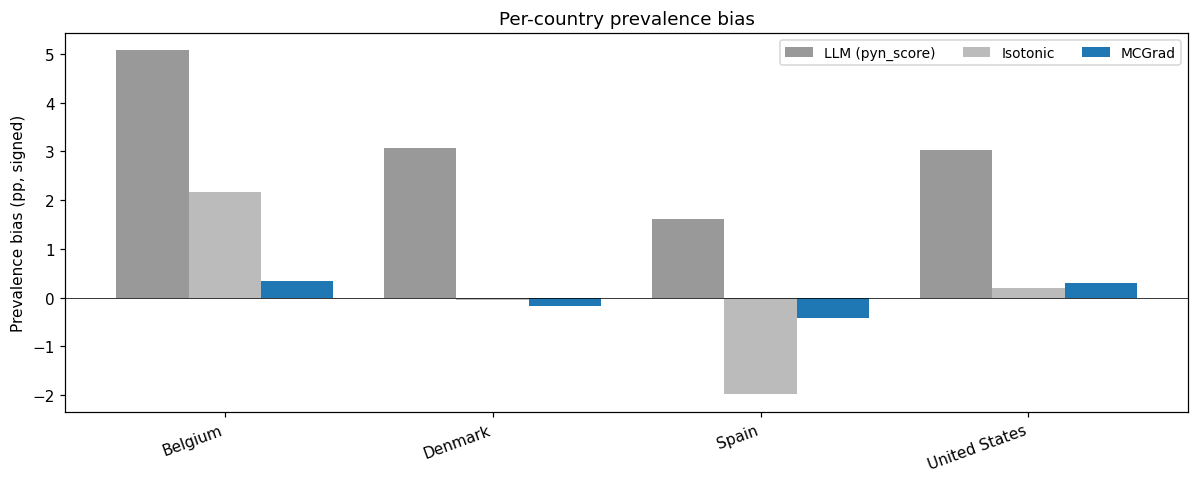

In [28]:
ESTIMATORS = list(score_map.keys())
COLORS = ['#999', '#bbb', '#1f77b4']

def plot_per_segment(df, segment_col, value_cols, ylabel, title,
                     ylim=None, axhline=None, fmt_label=None):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(df))
    width = 0.27
    for i, col in enumerate(value_cols):
        ax.bar(x + i * width, df[col], width, label=col, color=COLORS[i])
    if axhline is not None:
        ax.axhline(axhline, color='black', linewidth=0.5)
    ax.set_xticks(x + width)
    labels = df[segment_col].astype(str).str.replace('_', ' ')
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.legend(ncol=3, loc='best', fontsize=9)
    fig.tight_layout()
    plt.show()

plot_per_segment(
    by_country, 'country', ESTIMATORS,
    ylabel='Prevalence bias (pp, signed)',
    title='Per-country prevalence bias',
    axhline=0,
)

The LLM systematically over-estimates in every country (bias spans +1.6 to +5.1pp). Isotonic regression cuts the average bias down but introduces both directions of error across countries (−2.0 to +2.2pp) — its corrections are global, so per-segment bias just rebalances rather than disappearing. MCGrad's bias stays within ±0.5pp on every country (range −0.42 to +0.34, spread 0.76pp), at or below the level of pure sampling noise. The same MCGrad model that took global MCE σ from 22 to 4 also keeps per-country prevalence accurate.

### 5.2 Per-segment marginal precision
Calibrated probabilities also matter for **thresholding** — flagging items above a confidence cutoff for downstream action. The right precision metric here is more subtle than it might first look.
Two distinct quantities:
- **Average precision** at threshold T = the fraction of *all* flagged items (`score ≥ T`) that are positive. Items well above the threshold inflate this.
- **Marginal precision** at threshold T = the empirical positive rate of items *right at* the threshold — the items you'd flip from "ignore" to "flag" if you nudged the threshold down by ε. This is the **per-item risk you're taking on at the bar**.
For a calibrated score, marginal precision at T equals T by definition: `P(Y=1 | f(X) = T) = T`. For a *multi*calibrated score, marginal precision at T equals T **in every segment** — that's the per-item risk guarantee that lets you commit to a fixed false-positive bound everywhere your model is deployed.

**A practical note on the score we use here.** Law/crime is a low-prevalence label (~10.5%), so the `pyn_score` distribution is heavily concentrated at the low end — most documents are confidently *not* law/crime. To do a high-T marginal-precision analysis with adequate sample sizes, we work with the *reversed* prediction: **P(NOT law/crime) = 1 − pyn_score**.
Mathematically this is the same calibration question in mirror image (a calibrated score is calibrated for both `Y` and `1 − Y` simultaneously). Operationally it maps to a real workflow: a triage filter that lets us deprioritise documents the model is highly confident are *not* about law/crime. *"We want at most 10% per-item risk that a 'safe to skip' document is actually a law/crime case"* → set T = 0.9 on the reversed score.
We estimate marginal precision empirically by the empirical positive rate of items with `score ∈ [T − ε, T + ε]` — a small window around the threshold. Below: T = 0.9, ε = 0.025.

In [29]:
T = 0.9
EPS = 0.025

# Reverse the prediction direction: high score = high confidence NOT law/crime.
test_df['llm_neg'] = 1 - test_df[BASE_SCORE_COLUMN]
test_df['iso_neg'] = 1 - test_df[IR_SCORE_COLUMN]
test_df['mc_neg']  = 1 - test_df[MCGRAD_SCORE_COLUMN]
test_df['not_law_crime'] = 1 - test_df[LABEL_COLUMN]

score_map_neg = {
    'LLM (1 - pyn_score)': 'llm_neg',
    'Isotonic':            'iso_neg',
    'MCGrad':              'mc_neg',
}

def per_segment_marginal_precision(df, segment_col, score_cols, threshold, eps,
                                    label_col):
    rows = []
    for val, grp in df.groupby(segment_col):
        row = {segment_col: val, 'n': len(grp)}
        for label, col in score_cols.items():
            window = grp[(grp[col] >= threshold - eps) & (grp[col] <= threshold + eps)]
            row[f'{label} marg_prec'] = (
                window[label_col].mean() if len(window) > 0 else float('nan')
            )
            row[f'{label} n_in_window'] = len(window)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(segment_col).reset_index(drop=True)

mp_table = per_segment_marginal_precision(
    test_df, 'country', score_map_neg, T, EPS, label_col='not_law_crime',
)
mp_cols = [f'{e} marg_prec'   for e in score_map_neg]
n_cols  = [f'{e} n_in_window' for e in score_map_neg]
mp_table.style.format(
    {**{c: '{:.1%}' for c in mp_cols}, **{c: '{:.0f}' for c in n_cols}}
).set_caption(f'Marginal precision for P(NOT law/crime) in window [{T-EPS:.3f}, {T+EPS:.3f}], by country')

,country,n,LLM (1 - pyn_score) marg_prec,LLM (1 - pyn_score) n_in_window,Isotonic marg_prec,Isotonic n_in_window,MCGrad marg_prec,MCGrad n_in_window
0,Belgium,7920,98.1%,411,94.3%,333,91.3%,127
1,Denmark,4000,97.0%,265,92.4%,145,90.2%,82
2,Spain,8000,93.2%,385,83.7%,350,91.0%,167
3,United States,4000,93.8%,194,88.8%,89,89.5%,38


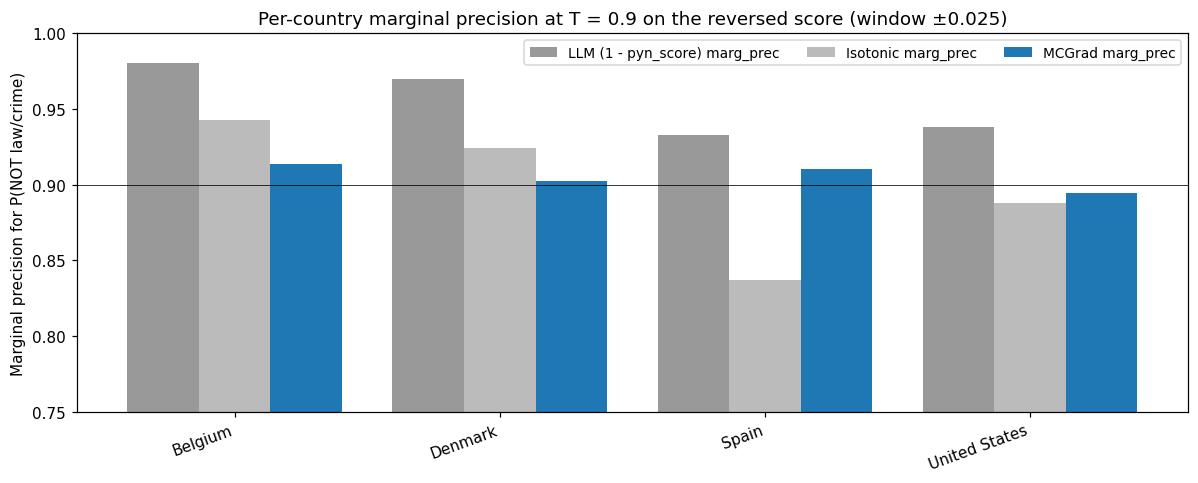

In [30]:
ESTIMATORS_NEG = list(score_map_neg.keys())
plot_per_segment(
    mp_table, 'country', mp_cols,
    ylabel='Marginal precision for P(NOT law/crime)',
    title=f'Per-country marginal precision at T = {T} on the reversed score (window ±{EPS})',
    ylim=(0.75, 1.0),
    axhline=T,
)

**MCGrad's marginal precision lands within ±1pp of T = 0.9 in every country** — a 1.9pp spread, dead-center on the dashed reference line. Raw LLM is systematically over-cautious — when it says "90% sure not law/crime", the empirical rate is 93–98% — and the *amount* of over-confidence varies by country. Isotonic gets closer to T on average but has the widest per-country spread (10.6pp), because global calibration redistributes errors rather than eliminating them per-segment.
**Operational implication.** Setting T = 0.9 on the MCGrad-calibrated score commits you to a per-item risk of about 10% in *every country*. The same threshold on the raw LLM score gives 2–7% per-country risk (over-cautious, with 5pp variation in how over-cautious); on isotonic it gives 6–16%. With MCGrad you can ship a triage rule that works across populations; with the alternatives, you're committing to risk levels that don't actually hold up where you deploy.
**A note on interpretation.** Strictly, the calibration guarantee is "marginal precision ≈ T", not "= T exactly". With finite samples, MCGrad's per-segment estimate moves around T by sampling noise. The pitch is that **MCGrad's per-segment band is much tighter** — and the band is *centered on the threshold you set*, not 5–8pp away from it.

## 6. Next Steps
This tutorial showed the standard MCGrad workflow on an LLM classifier in the in-distribution setting. From here:
- **[Tutorial 01 — MCGrad core algorithm](01_mcgrad_core.ipynb)** — The same workflow on a non-LLM (logistic regression) base model, useful as a side-by-side reference.
- **[Methodology docs](https://mcgrad.dev/docs/methodology)** — How MCGrad detects and corrects miscalibration internally.
- **[API reference](https://mcgrad.readthedocs.io/)** — Constructor arguments, hyperparameter tuning, model serialization for production.
- **[The MCGrad-for-measurement paper](https://github.com/facebookresearch/multicalibrated_llm_measurement)** — Theoretical results on why multicalibration is sufficient for unbiased prevalence estimation under covariate shift, and a fuller experimental treatment.